In [1]:
"""
==========================================================
STREAMFLIX CONTENT ANALYTICS
Phase 3 - Business KPI Calculation
Author : Sujal
==========================================================
"""

import os
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)
pd.set_option("display.width",150)

os.makedirs("reports",exist_ok=True)
os.makedirs("logs",exist_ok=True)
os.makedirs("charts",exist_ok=True)

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    handlers=[

        logging.FileHandler(

            f"logs/phase3_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

        ),

        logging.StreamHandler()

    ]

)

logger=logging.getLogger(__name__)

logger.info("="*80)
logger.info("PHASE 3 KPI CALCULATION STARTED")
logger.info("="*80)

2026-07-21 22:38:51,297 | INFO | ================================================================================
2026-07-21 22:38:51,299 | INFO | PHASE 3 KPI CALCULATION STARTED
2026-07-21 22:38:51,300 | INFO | ================================================================================


In [2]:
subscribers=pd.read_csv(

    "data/cleaned/subscribers_clean.csv",

    parse_dates=["signup_date","churn_date"]

)

titles=pd.read_csv(

    "data/cleaned/titles_clean.csv",

    parse_dates=["date_added","license_expiry"]

)

watch_history=pd.read_csv(

    "data/cleaned/watch_history_clean.csv",

    parse_dates=["watch_date"]

)

ratings=pd.read_csv(

    "data/cleaned/ratings_clean.csv",

    parse_dates=["rating_date"]

)

reviews=pd.read_csv(

    "data/cleaned/reviews_clean.csv",

    parse_dates=["review_date"]

)

watchlist=pd.read_csv(

    "data/cleaned/watchlist_clean.csv",

    parse_dates=["added_date"]

)

logger.info("Datasets Loaded Successfully")

2026-07-21 22:38:54,946 | INFO | Datasets Loaded Successfully


In [3]:
eda=watch_history.merge(

    subscribers,

    on="subscriber_id",

    how="left"

)

eda=eda.merge(

    titles,

    on="title_id",

    how="left"

)

eda["Watch Hours"]=eda["watch_duration_min"]/60

eda["Month"]=eda["watch_date"].dt.to_period("M")

eda["Year"]=eda["watch_date"].dt.year

logger.info("Merged Dataset Created")

2026-07-21 22:38:56,411 | INFO | Merged Dataset Created


In [4]:
kpi={}

In [5]:
total_subscribers=subscribers["subscriber_id"].nunique()

logger.info(f"Total Subscribers : {total_subscribers}")

kpi["Total Subscribers"]=total_subscribers

2026-07-21 22:38:56,454 | INFO | Total Subscribers : 15000


In [6]:
active=subscribers["is_active"].sum()

logger.info(f"Active Subscribers : {active}")

kpi["Active Subscribers"]=active

2026-07-21 22:38:56,476 | INFO | Active Subscribers : 11199


In [7]:
active_rate=round(
    (active/total_subscribers)*100,
    2
)

logger.info(f"Active Rate : {active_rate}%")

kpi["Active Rate (%)"]=active_rate

2026-07-21 22:38:56,499 | INFO | Active Rate : 74.66%


In [8]:
churned=subscribers["churn_date"].notna().sum()

logger.info(f"Churned Subscribers : {churned}")

kpi["Churned Subscribers"]=churned

2026-07-21 22:38:56,552 | INFO | Churned Subscribers : 15000


In [9]:
churn_rate=round(
    (churned/total_subscribers)*100,
    2
)

logger.info(f"Churn Rate : {churn_rate}%")

kpi["Churn Rate (%)"]=churn_rate

2026-07-21 22:38:56,579 | INFO | Churn Rate : 100.0%


In [10]:
watch_hours=round(
    eda["Watch Hours"].sum(),
    2
)

logger.info(f"Total Watch Hours : {watch_hours}")

kpi["Total Watch Hours"]=watch_hours

2026-07-21 22:38:56,680 | INFO | Total Watch Hours : 3333467.73


In [11]:
avg_watch=round(
    eda["Watch Hours"].mean(),
    2
)

logger.info(f"Average Watch Hours : {avg_watch}")

kpi["Average Watch Hours"]=avg_watch

2026-07-21 22:38:56,709 | INFO | Average Watch Hours : 5.13


In [12]:
completion=round(
    eda["completion_pct"].mean(),
    2
)

logger.info(f"Completion Rate : {completion}%")

kpi["Completion Rate (%)"]=completion

2026-07-21 22:38:56,765 | INFO | Completion Rate : 65.31%


In [13]:
total_revenue=round(
    subscribers["monthly_price_usd"].sum(),
    2
)

logger.info(f"Monthly Revenue : ${total_revenue}")

kpi["Monthly Revenue"]=total_revenue

2026-07-21 22:38:56,800 | INFO | Monthly Revenue : $227772.0


In [14]:
MRR=round(
    subscribers.loc[
        subscribers["is_active"]==True,
        "monthly_price_usd"
    ].sum(),
    2
)

logger.info(f"MRR : ${MRR}")

kpi["MRR"]=MRR

2026-07-21 22:38:56,909 | INFO | MRR : $175868.51


In [15]:
ARPU=round(
    MRR/active,
    2
)

logger.info(f"ARPU : ${ARPU}")

kpi["ARPU"]=ARPU

2026-07-21 22:38:56,999 | INFO | ARPU : $15.7


In [16]:
total_titles=titles["title_id"].nunique()

logger.info(f"Total Titles : {total_titles}")

kpi["Total Titles"]=total_titles

2026-07-21 22:38:57,482 | INFO | Total Titles : 9000


In [17]:
movies=titles[
    titles["type"]=="Movie"
].shape[0]

logger.info(f"Movies : {movies}")

kpi["Movies"]=movies

2026-07-21 22:38:57,541 | INFO | Movies : 5336


In [18]:
tvshows=titles[
    titles["type"]=="TV Show"
].shape[0]

logger.info(f"TV Shows : {tvshows}")

kpi["TV Shows"]=tvshows

2026-07-21 22:38:57,560 | INFO | TV Shows : 3664


In [19]:
original=titles["is_original"].sum()

logger.info(f"Original Titles : {original}")

kpi["Original Titles"]=original

2026-07-21 22:38:57,581 | INFO | Original Titles : 1966


In [20]:
licensed=len(titles)-original

logger.info(f"Licensed Titles : {licensed}")

kpi["Licensed Titles"]=licensed

2026-07-21 22:38:57,599 | INFO | Licensed Titles : 7034


In [21]:
rating=round(
    ratings["rating"].mean(),
    2
)

logger.info(f"Average Rating : {rating}")

kpi["Average Rating"]=rating

2026-07-21 22:38:57,616 | INFO | Average Rating : 3.55


In [22]:
total_reviews=len(reviews)

logger.info(f"Reviews : {total_reviews}")

kpi["Total Reviews"]=total_reviews

2026-07-21 22:38:57,637 | INFO | Reviews : 110000


In [23]:
watchlist_items=len(watchlist)

logger.info(f"Watchlist Items : {watchlist_items}")

kpi["Watchlist Items"]=watchlist_items

2026-07-21 22:38:57,658 | INFO | Watchlist Items : 65000


In [24]:
kpi_df=pd.DataFrame(
    kpi.items(),
    columns=[
        "KPI",
        "Value"
    ]
)

print(kpi_df)

                    KPI       Value
0     Total Subscribers    15000.00
1    Active Subscribers    11199.00
2       Active Rate (%)       74.66
3   Churned Subscribers    15000.00
4        Churn Rate (%)      100.00
5     Total Watch Hours  3333467.73
6   Average Watch Hours        5.13
7   Completion Rate (%)       65.31
8       Monthly Revenue   227772.00
9                   MRR   175868.51
10                 ARPU       15.70
11         Total Titles     9000.00
12               Movies     5336.00
13             TV Shows     3664.00
14      Original Titles     1966.00
15      Licensed Titles     7034.00
16       Average Rating        3.55
17        Total Reviews   110000.00
18      Watchlist Items    65000.00


In [25]:
kpi_df.to_csv(
    "reports/KPI_Summary.csv",
    index=False
)

logger.info("KPI Summary Exported")

2026-07-21 22:38:57,724 | INFO | KPI Summary Exported


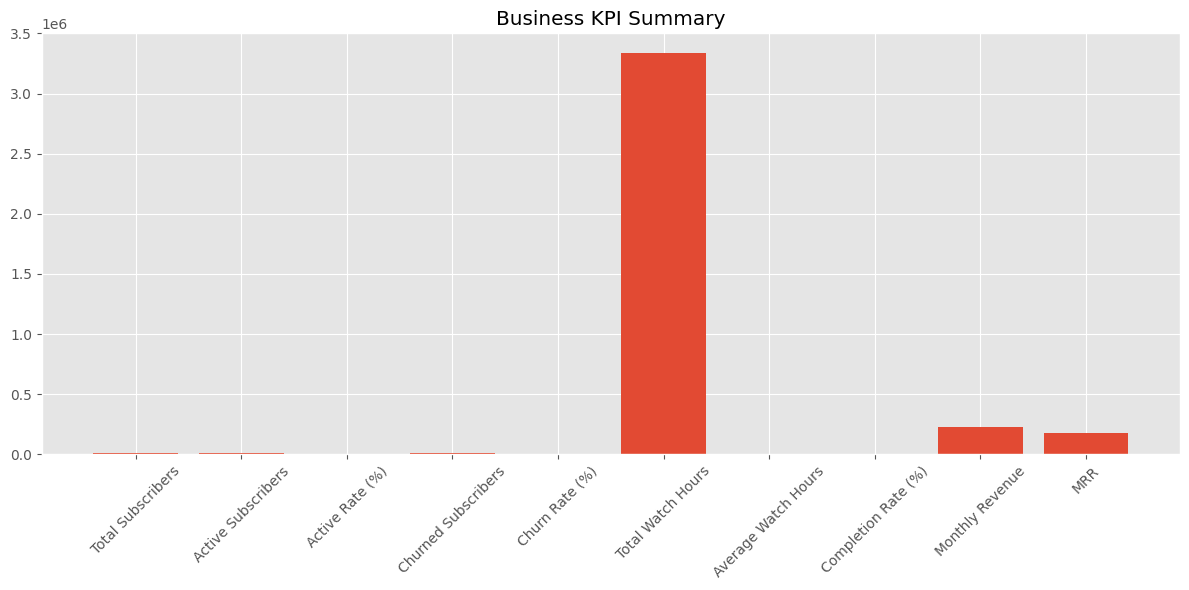

In [26]:
plot_df=kpi_df.copy()

plot_df=plot_df.iloc[:10]

plt.figure(figsize=(12,6))

plt.bar(
    plot_df["KPI"],
    plot_df["Value"]
)

plt.xticks(rotation=45)

plt.title("Business KPI Summary")

plt.tight_layout()

plt.savefig(
    "charts/KPI_Summary.png",
    dpi=300
)

plt.show()

In [27]:
print("="*80)

print("PHASE 3 - PART 1 COMPLETED")

print("="*80)

print(kpi_df)

print("="*80)

PHASE 3 - PART 1 COMPLETED
                    KPI       Value
0     Total Subscribers    15000.00
1    Active Subscribers    11199.00
2       Active Rate (%)       74.66
3   Churned Subscribers    15000.00
4        Churn Rate (%)      100.00
5     Total Watch Hours  3333467.73
6   Average Watch Hours        5.13
7   Completion Rate (%)       65.31
8       Monthly Revenue   227772.00
9                   MRR   175868.51
10                 ARPU       15.70
11         Total Titles     9000.00
12               Movies     5336.00
13             TV Shows     3664.00
14      Original Titles     1966.00
15      Licensed Titles     7034.00
16       Average Rating        3.55
17        Total Reviews   110000.00
18      Watchlist Items    65000.00


In [28]:

plan_revenue=(
    subscribers
    .groupby("plan_type")
    .agg(
        Subscribers=("subscriber_id","count"),
        Revenue=("monthly_price_usd","sum"),
        Avg_Revenue=("monthly_price_usd","mean")
    )
    .reset_index()
)

logger.info("Revenue by Plan Calculated")

print(plan_revenue)

2026-07-21 22:38:58,791 | INFO | Revenue by Plan Calculated


        plan_type  Subscribers    Revenue  Avg_Revenue
0  Basic with Ads         4458   31161.42         6.99
1         Premium         4442  102121.58        22.99
2        Standard         6100   94489.00        15.49


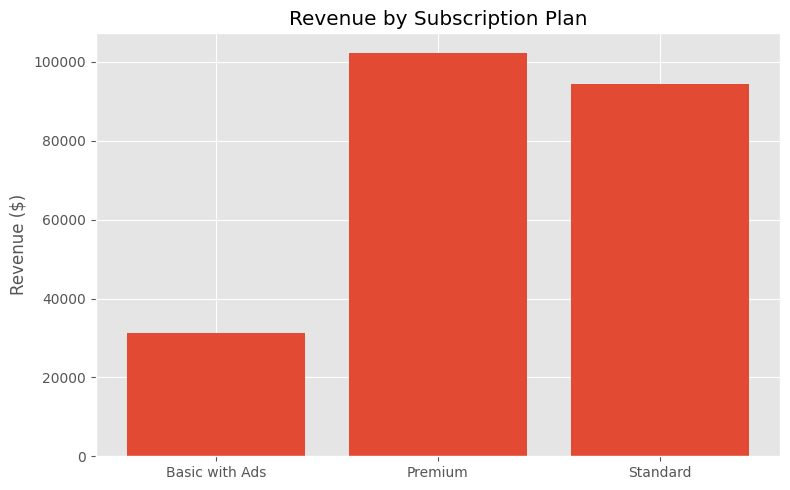

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    plan_revenue["plan_type"],
    plan_revenue["Revenue"]
)

plt.title("Revenue by Subscription Plan")

plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.savefig(
    "charts/Revenue_by_Plan.png",
    dpi=300
)

plt.show()

In [32]:
country_kpi=(
    eda
    .groupby("country_x")
    .agg(
        Subscribers=("subscriber_id","nunique"),
        Watch_Hours=("Watch Hours","sum"),
        Revenue=("monthly_price_usd","sum"),
        Avg_Completion=("completion_pct","mean")
    )

    .sort_values(
        by="Watch_Hours",
        ascending=False
    )
)

logger.info("Country KPI Created")

country_kpi.head()

country_kpi.to_csv("reports/Country_KPI.csv")

2026-07-21 22:41:08,008 | INFO | Country KPI Created


In [33]:
device_kpi=(
    eda
    .groupby("device")
    .agg(
        Sessions=("watch_id","count"),
        Watch_Hours=("Watch Hours","sum"),
        Avg_Completion=("completion_pct","mean")
    )
    .sort_values(
        by="Watch_Hours",
        ascending=False
    )
)

device_kpi

,Sessions,Watch_Hours,Avg_Completion
device,,,
Smart TV,221446,1.133405e+06,65.324256
Mobile,175605,9.005267e+05,65.271014
Laptop,96408,4.966748e+05,65.366382
Tablet,65276,3.314516e+05,65.339797
Game Console,52322,2.700856e+05,65.305302
Streaming Stick,38943,2.013239e+05,65.233367


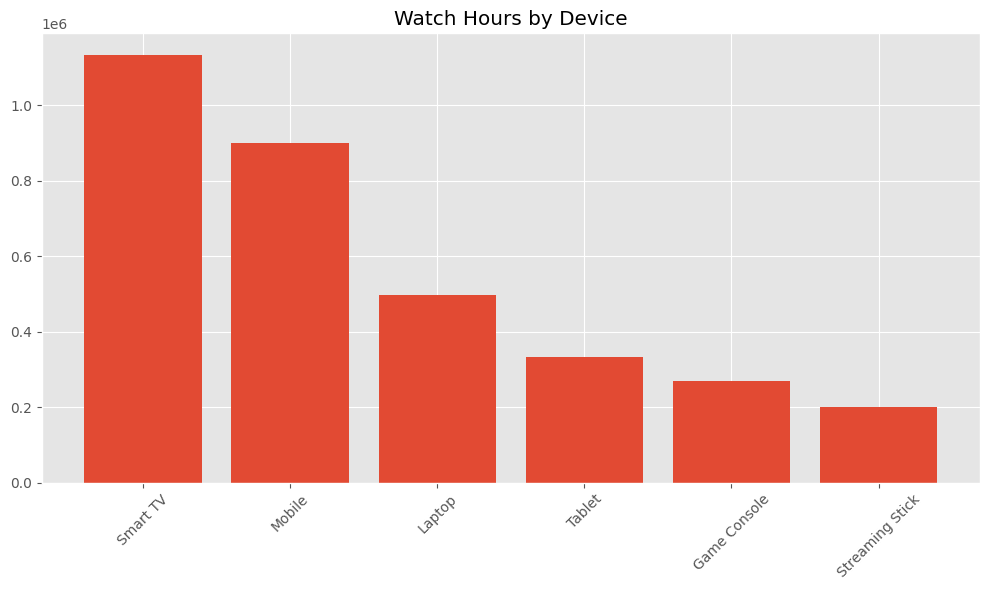

In [34]:
plt.figure(figsize=(10,6))

plt.bar(
    device_kpi.index,
    device_kpi["Watch_Hours"]
)

plt.xticks(rotation=45)

plt.title("Watch Hours by Device")

plt.tight_layout()

plt.savefig(
    "charts/Device_Watch_Hours.png",
    dpi=300
)

plt.show()

In [35]:
total_watchlist=watchlist.shape[0]

converted=watchlist[
    watchlist["watched"]==True
].shape[0]

conversion=round(
    converted/total_watchlist*100,
    2
)

logger.info(
    f"Watchlist Conversion : {conversion}%"
)

kpi["Watchlist Conversion (%)"]=conversion

2026-07-21 22:41:18,831 | INFO | Watchlist Conversion : 46.23%


In [36]:
original_hours=round(
    eda.loc[
        eda["is_original"]==True,
        "Watch Hours"
    ].sum(),
    2
)

total_hours=round(
    eda["Watch Hours"].sum(),
    2
)

share=round(
    original_hours/total_hours*100,
    2
)

logger.info(
    f"Original Share : {share}%"
)

kpi["Original Watch Hour Share (%)"]=share

2026-07-21 22:41:20,329 | INFO | Original Share : 27.17%


In [37]:
genre_kpi=(
    eda
    .groupby("primary_genre")
    .agg(
        Watch_Hours=("Watch Hours","sum"),
        Views=("watch_id","count"),
        Avg_Completion=("completion_pct","mean")
    )

    .sort_values(
        by="Watch_Hours",
        ascending=False
    )
)

genre_kpi.head()

,Watch_Hours,Views,Avg_Completion
primary_genre,,,
Drama,501884.466667,95624,65.104168
Comedy,423149.053333,84455,65.316334
Action,393171.916667,77300,64.812501
Thriller,307024.663333,58589,65.307925
Documentary,291216.898333,57786,65.127758


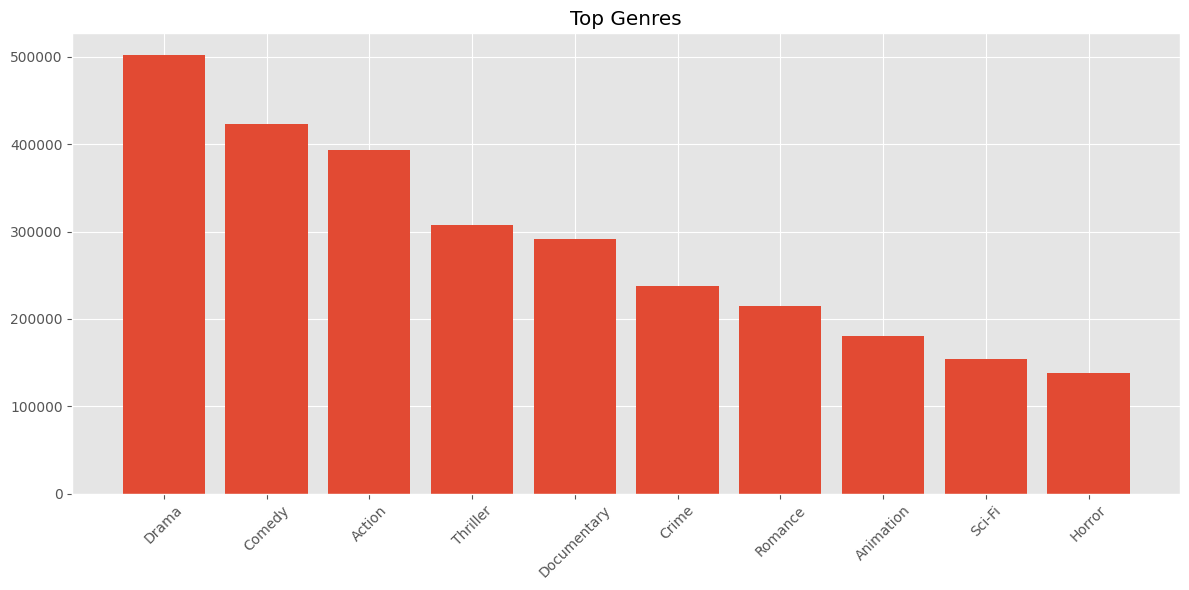

In [38]:
plt.figure(figsize=(12,6))

plt.bar(
    genre_kpi.head(10).index,
    genre_kpi.head(10)["Watch_Hours"]
)

plt.xticks(rotation=45)

plt.title("Top Genres")

plt.tight_layout()

plt.savefig(
    "charts/Top_Genres.png",
    dpi=300
)

plt.show()

In [39]:
subscriber_watch=(
    eda
    .groupby("subscriber_id")
    ["Watch Hours"]
    .sum()
)

avg_watch_time=round(
    subscriber_watch.mean(),
    2
)

logger.info(
    f"Average Watch Time : {avg_watch_time}"
)

kpi["Average Watch Time per Subscriber"]=avg_watch_time

2026-07-21 22:41:24,608 | INFO | Average Watch Time : 222.26


In [40]:
popular_titles=(
    eda
    .groupby("title_name")
    .agg(
        Watch_Hours=("Watch Hours","sum"),
        Plays=("watch_id","count"),
        Completion=("completion_pct","mean")
    )
    .sort_values(
        by="Watch_Hours",
        ascending=False
    )
)

popular_titles.head(10)

,Watch_Hours,Plays,Completion
title_name,,,
Gilded Throne,35443.440000,3482,72.022372
The Shadows of Marseille IV,22538.220000,4436,60.969094
The Cipher of Madrid II,16659.995000,3028,67.098184
The Reckoning of Lagos II,14778.550000,614,61.717264
Hamburg Frequency IV,13963.478333,1792,70.838002
Broken Toronto II,11902.905000,1043,62.704794
Jakarta Odyssey IV,11440.023333,1513,67.509518
Marseille Circuit II,10967.338333,565,65.575398
The Sanctuary of Toronto III,10844.841667,460,71.878478


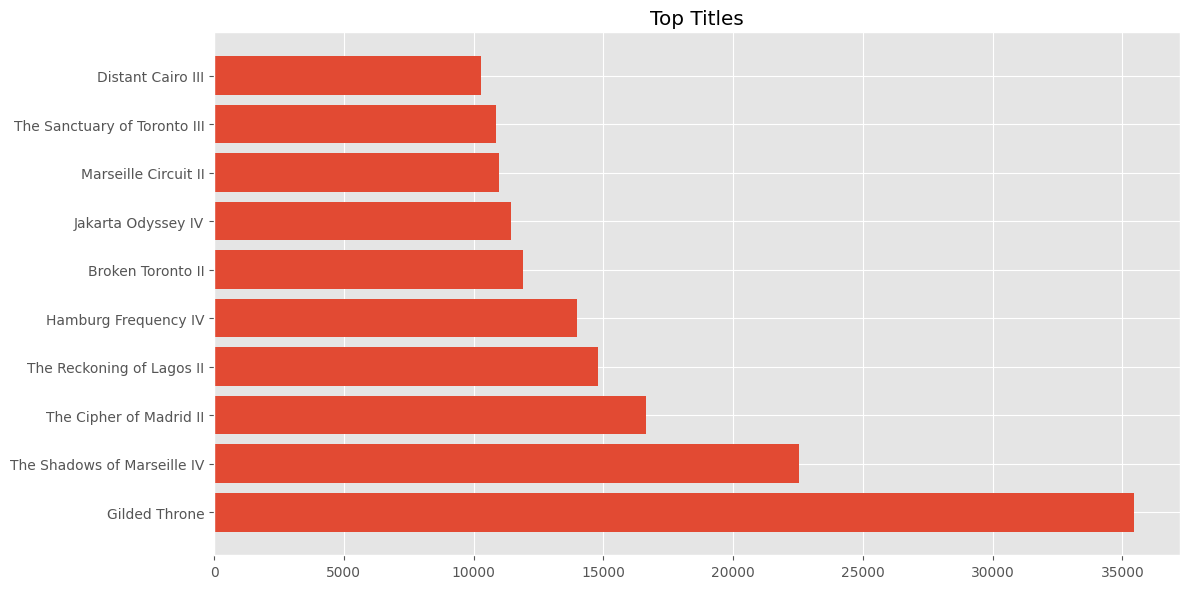

In [41]:
plt.figure(figsize=(12,6))

plt.barh(
    popular_titles.head(10).index,
    popular_titles.head(10)["Watch_Hours"]
)

plt.title("Top Titles")

plt.tight_layout()

plt.savefig(
    "charts/Top_Titles.png",
    dpi=300
)

plt.show()

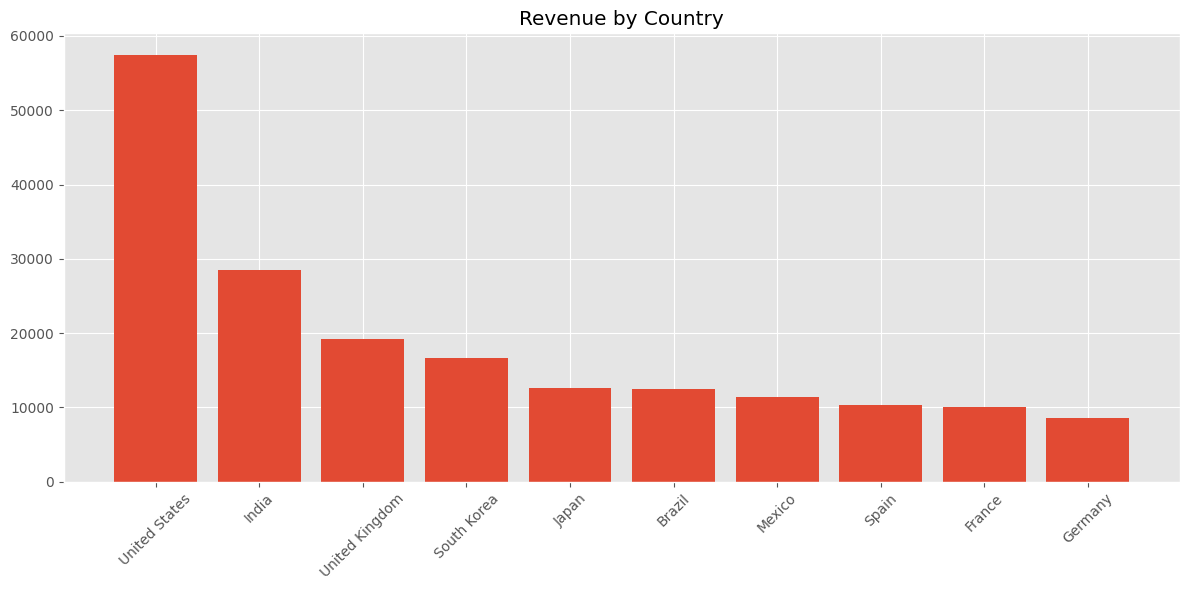

In [42]:
country_revenue=(
    subscribers
    .groupby("country")
    ["monthly_price_usd"]
    .sum()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(12,6))

plt.bar(
    country_revenue.head(10).index,
    country_revenue.head(10).values
)

plt.xticks(rotation=45)

plt.title("Revenue by Country")

plt.tight_layout()

plt.savefig(
    "charts/Country_Revenue.png",
    dpi=300
)

plt.show()

In [43]:
kpi_df=pd.DataFrame(
    kpi.items(),
    columns=[
        "KPI",
        "Value"
    ]
)

kpi_df.to_csv(
    "reports/KPI_Summary.csv",
    index=False
)

logger.info("Updated KPI Summary Exported")

2026-07-21 22:41:34,412 | INFO | Updated KPI Summary Exported


In [44]:
plan_revenue.to_csv(
    "reports/Revenue_by_Plan.csv",
    index=False
)

device_kpi.to_csv(
    "reports/Device_KPI.csv"
)

genre_kpi.to_csv(
    "reports/Genre_KPI.csv"
)

popular_titles.to_csv(
    "reports/Popular_Titles.csv"
)

In [45]:
print("="*80)

print("PHASE 3 - PART 2 COMPLETED")

print("="*80)

print()

print("Revenue by Plan")

print(plan_revenue)

print()

print("Top Genres")

print(genre_kpi.head())

print()

print("Top Titles")

print(popular_titles.head())

print("="*80)

PHASE 3 - PART 2 COMPLETED

Revenue by Plan
        plan_type  Subscribers    Revenue  Avg_Revenue
0  Basic with Ads         4458   31161.42         6.99
1         Premium         4442  102121.58        22.99
2        Standard         6100   94489.00        15.49

Top Genres
                 Watch_Hours  Views  Avg_Completion
primary_genre                                      
Drama          501884.466667  95624       65.104168
Comedy         423149.053333  84455       65.316334
Action         393171.916667  77300       64.812501
Thriller       307024.663333  58589       65.307925
Documentary    291216.898333  57786       65.127758

Top Titles
                              Watch_Hours  Plays  Completion
title_name                                                  
Gilded Throne                35443.440000   3482   72.022372
The Shadows of Marseille IV  22538.220000   4436   60.969094
The Cipher of Madrid II      16659.995000   3028   67.098184
The Reckoning of Lagos II    14778.550000  

2026-07-21 22:41:38,972 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-21 22:41:38,979 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


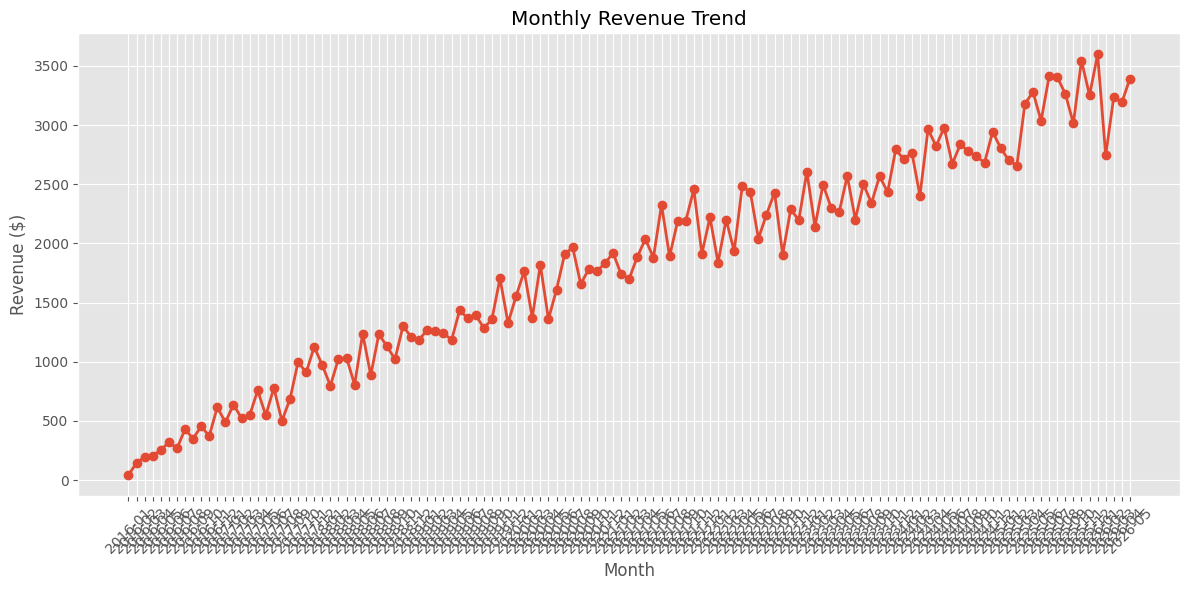

2026-07-21 22:41:40,672 | INFO | Monthly Revenue Trend Generated


In [46]:
# --------------------------------------------------------
# MONTHLY REVENUE TREND
# --------------------------------------------------------

monthly_revenue = (

    subscribers

    .groupby(

        subscribers["signup_date"].dt.to_period("M")

    )["monthly_price_usd"]

    .sum()

)

monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(

    monthly_revenue.index,

    monthly_revenue.values,

    marker="o",

    linewidth=2

)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue ($)")

plt.grid(True)

plt.tight_layout()

plt.savefig(

    "charts/Monthly_Revenue_Trend.png",

    dpi=300

)

plt.show()

logger.info("Monthly Revenue Trend Generated")

2026-07-21 22:41:45,563 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-21 22:41:45,576 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


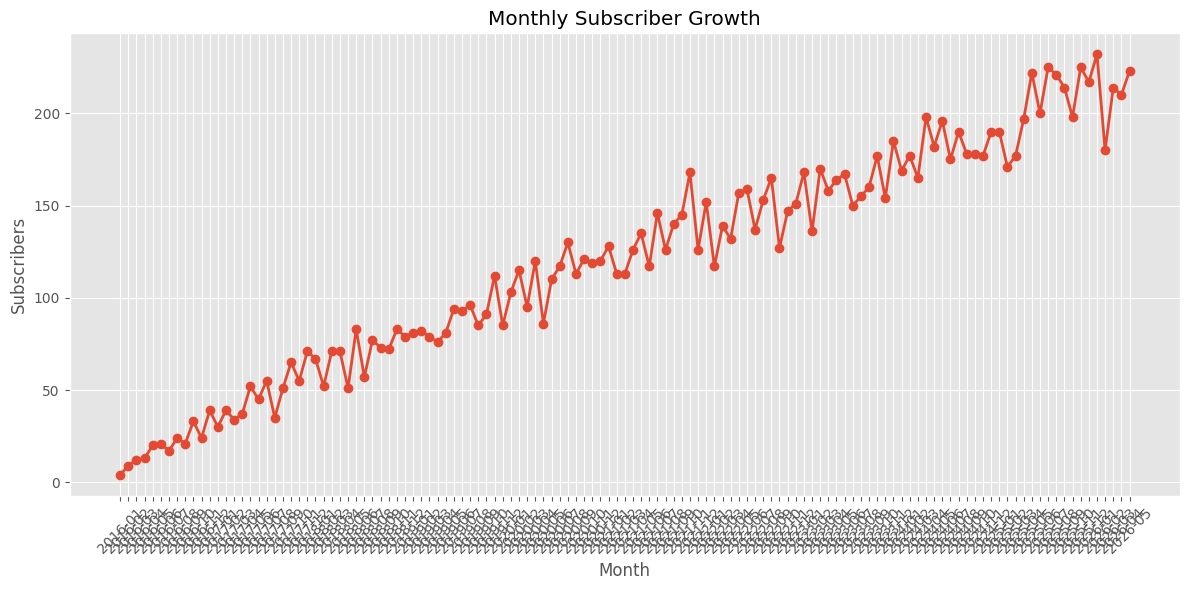

In [47]:
monthly_subscribers=(

    subscribers

    .groupby(

        subscribers["signup_date"].dt.to_period("M")

    )

    .size()

)

monthly_subscribers.index=monthly_subscribers.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(

    monthly_subscribers.index,

    monthly_subscribers.values,

    marker="o",

    linewidth=2

)

plt.xticks(rotation=45)

plt.title("Monthly Subscriber Growth")

plt.xlabel("Month")

plt.ylabel("Subscribers")

plt.grid(True)

plt.tight_layout()

plt.savefig(

    "charts/Monthly_Subscriber_Growth.png",

    dpi=300

)

plt.show()

2026-07-21 22:41:51,720 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-21 22:41:51,726 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


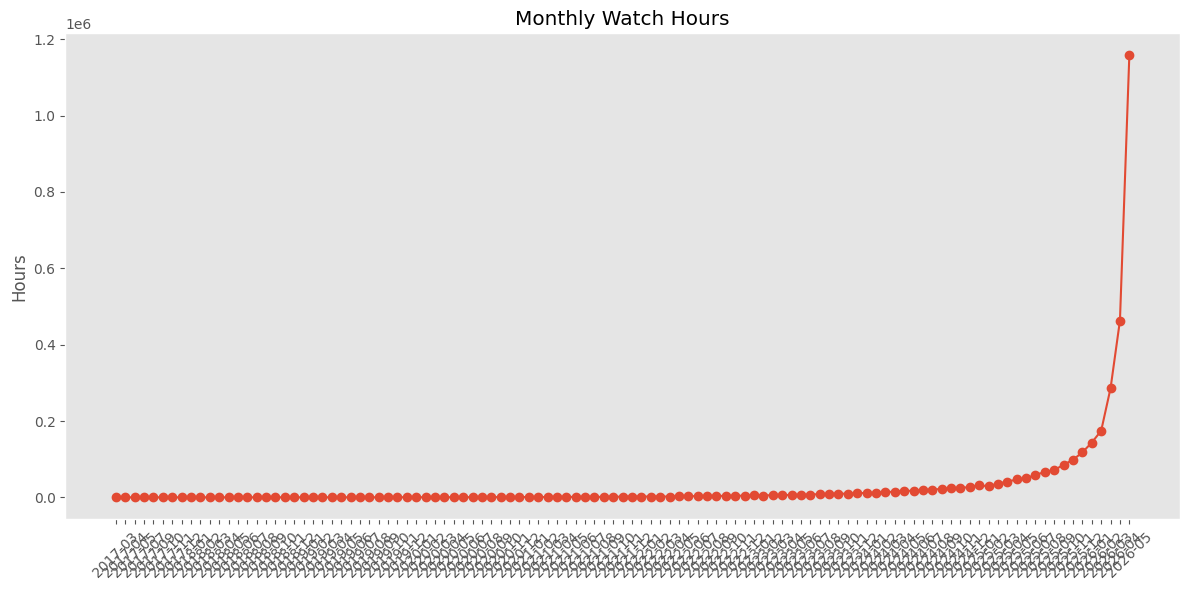

In [48]:
monthly_watch=(

    eda

    .groupby(

        eda["watch_date"].dt.to_period("M")

    )["Watch Hours"]

    .sum()

)

monthly_watch.index=monthly_watch.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(

    monthly_watch.index,

    monthly_watch.values,

    marker="o"

)

plt.xticks(rotation=45)

plt.title("Monthly Watch Hours")

plt.ylabel("Hours")

plt.grid()

plt.tight_layout()

plt.savefig(

    "charts/Monthly_Watch_Hours.png",

    dpi=300

)

plt.show()

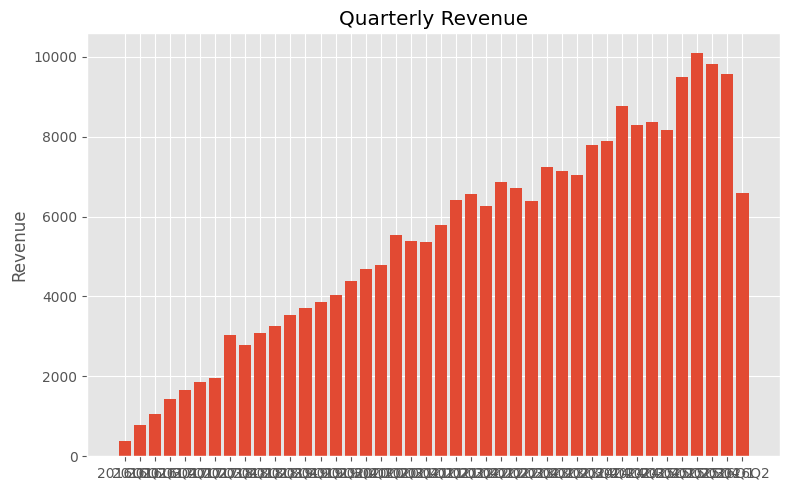

In [49]:
quarterly=(

    subscribers

    .groupby(

        subscribers["signup_date"].dt.to_period("Q")

    )["monthly_price_usd"]

    .sum()

)

quarterly.index=quarterly.index.astype(str)

plt.figure(figsize=(8,5))

plt.bar(

    quarterly.index,

    quarterly.values

)

plt.title("Quarterly Revenue")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(

    "charts/Quarterly_Revenue.png",

    dpi=300

)

plt.show()

2026-07-21 22:42:05,174 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-21 22:42:05,181 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


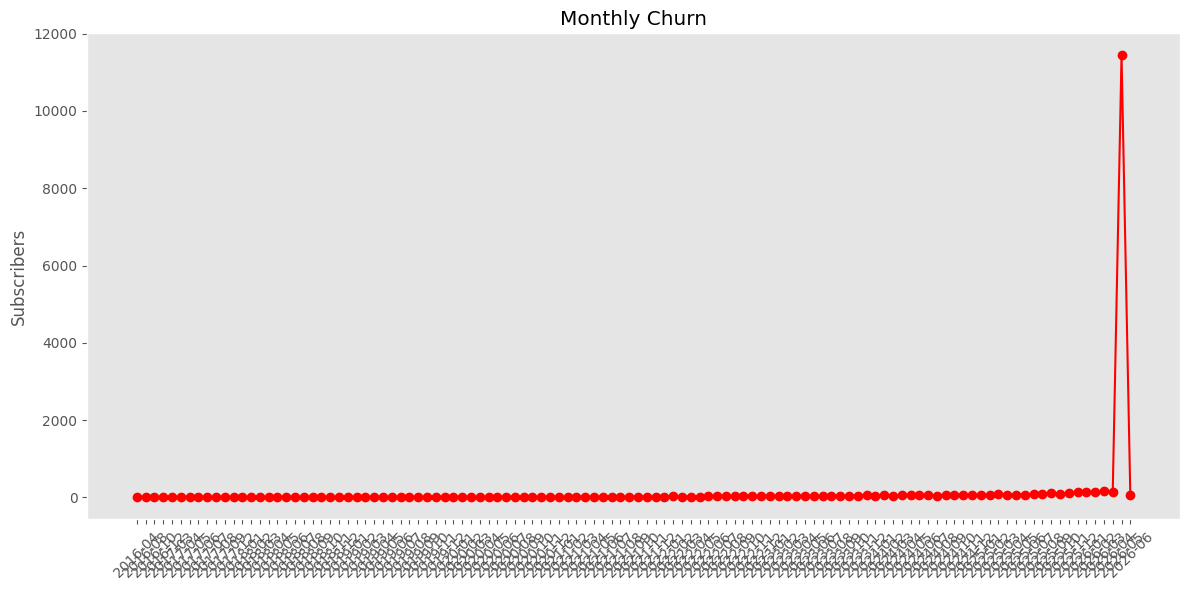

In [50]:
monthly_churn=(

    subscribers

    .dropna(subset=["churn_date"])

    .groupby(

        subscribers["churn_date"].dt.to_period("M")

    )

    .size()

)

monthly_churn.index=monthly_churn.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(

    monthly_churn.index,

    monthly_churn.values,

    marker="o",

    color="red"

)

plt.xticks(rotation=45)

plt.title("Monthly Churn")

plt.ylabel("Subscribers")

plt.grid()

plt.tight_layout()

plt.savefig(

    "charts/Monthly_Churn.png",

    dpi=300

)

plt.show()

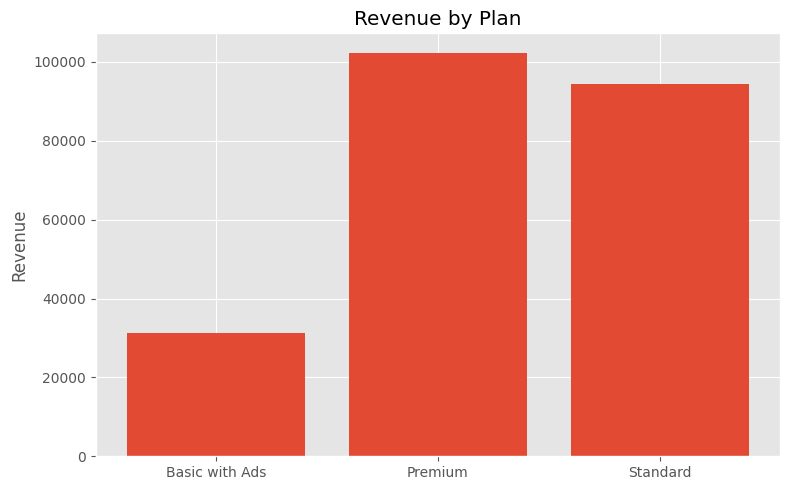

In [51]:
plan_rev=(

    subscribers

    .groupby("plan_type")

    ["monthly_price_usd"]

    .sum()

)

plt.figure(figsize=(8,5))

plt.bar(

    plan_rev.index,

    plan_rev.values

)

plt.title("Revenue by Plan")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(

    "charts/Revenue_by_Plan_Trend.png",

    dpi=300

)

plt.show()

In [52]:
executive=pd.DataFrame({

    "Metric":[

        "Subscribers",

        "Active Rate",

        "Churn Rate",

        "MRR",

        "ARPU",

        "Watch Hours",

        "Completion",

        "Average Rating"

    ],

    "Value":[

        total_subscribers,

        active_rate,

        churn_rate,

        MRR,

        ARPU,

        watch_hours,

        completion,

        rating

    ]

})

executive

,Metric,Value
0,Subscribers,15000.00
1,Active Rate,74.66
2,Churn Rate,100.00
3,MRR,175868.51
4,ARPU,15.70
5,Watch Hours,3333467.73
6,Completion,65.31
7,Average Rating,3.55


In [53]:
executive.to_csv(
    "reports/Executive_KPI.csv",
    index=False
)

logger.info("Executive KPI Exported")

2026-07-21 22:42:17,400 | INFO | Executive KPI Exported


In [54]:
top_country=(

    subscribers

    .groupby("country")

    .agg(

        Subscribers=("subscriber_id","count"),

        Revenue=("monthly_price_usd","sum")

    )

    .sort_values(

        by="Revenue",

        ascending=False

    )

)

top_country.head(10)

top_country.to_csv(
    "reports/Top_Country_KPI.csv"
)

In [55]:
recommendations=[]

if churn_rate>10:

    recommendations.append(

        "High churn detected. Improve retention campaigns."

    )

if completion<80:

    recommendations.append(

        "Improve content recommendation system."

    )

if share<40:

    recommendations.append(

        "Increase investment in Original content."

    )

if ARPU<12:

    recommendations.append(

        "Upsell premium subscription plans."

    )

if rating<4:

    recommendations.append(

        "Improve content quality."

    )

recommendation_df=pd.DataFrame(

    recommendations,

    columns=["Recommendation"]

)

recommendation_df

recommendation_df.to_csv(
    "reports/Business_Recommendations.csv",
    index=False
)

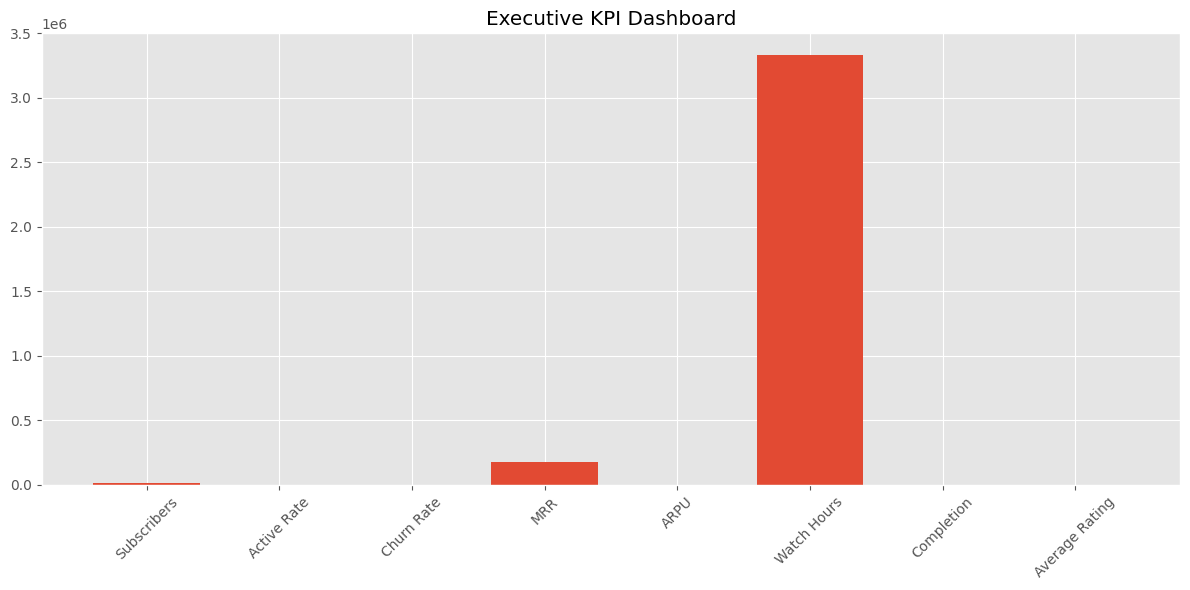

In [56]:
plt.figure(figsize=(12,6))

plt.bar(

    executive["Metric"],

    executive["Value"]

)

plt.xticks(rotation=45)

plt.title("Executive KPI Dashboard")

plt.tight_layout()

plt.savefig(

    "charts/Executive_Dashboard.png",

    dpi=300

)

plt.show()

In [57]:
trend=pd.DataFrame({

    "Month":monthly_watch.index,

    "Watch Hours":monthly_watch.values

})

trend["Growth %"]=trend["Watch Hours"].pct_change()*100

trend

trend.to_csv(
    "reports/Monthly_Watch_Trend.csv",
    index=False
)

In [58]:
with open(

    "reports/Executive_Report.txt",

    "w",

    encoding="utf-8"

) as file:

    file.write("="*80+"\n")

    file.write("STREAMFLIX EXECUTIVE KPI REPORT\n")

    file.write("="*80+"\n\n")

    for i,row in executive.iterrows():

        file.write(

            f"{row['Metric']} : {row['Value']}\n"

        )

    file.write("\n")

    file.write("Business Recommendations\n")

    file.write("-"*40+"\n")

    for rec in recommendations:

        file.write(rec+"\n")

logger.info("Executive Report Generated")

2026-07-21 22:42:25,025 | INFO | Executive Report Generated


In [59]:
print("="*80)

print("PHASE 3 - PART 3 COMPLETED")

print("="*80)

print()

print(executive)

print()

print("Recommendations")

print(recommendation_df)

print("="*80)

PHASE 3 - PART 3 COMPLETED

           Metric       Value
0     Subscribers    15000.00
1     Active Rate       74.66
2      Churn Rate      100.00
3             MRR   175868.51
4            ARPU       15.70
5     Watch Hours  3333467.73
6      Completion       65.31
7  Average Rating        3.55

Recommendations
                                      Recommendation
0  High churn detected. Improve retention campaigns.
1             Improve content recommendation system.
2           Increase investment in Original content.
3                           Improve content quality.


In [60]:
# --------------------------------------------------------
# COHORT ANALYSIS
# --------------------------------------------------------

cohort = subscribers.copy()

cohort["Signup Month"] = cohort["signup_date"].dt.to_period("M")

cohort["Churn Month"] = cohort["churn_date"].dt.to_period("M")

logger.info("Cohort Dataset Created")

2026-07-21 22:42:28,617 | INFO | Cohort Dataset Created


In [61]:
cohort_summary=(

    cohort

    .groupby("Signup Month")

    .agg(

        Subscribers=("subscriber_id","count"),

        Active=("is_active","sum")

    )

)

cohort_summary["Retention %"]=round(

    cohort_summary["Active"]

    /

    cohort_summary["Subscribers"]

    *100,

    2

)

cohort_summary

cohort_summary.to_csv(
    "reports/Cohort_Summary.csv"
)

logger.info("Cohort Summary Exported")

2026-07-21 22:42:30,005 | INFO | Cohort Summary Exported


In [62]:
retention=(

    subscribers

    .groupby(

        subscribers["signup_date"].dt.to_period("M")

    )

    .agg(

        Subscribers=("subscriber_id","count"),

        Active=("is_active","sum")

    )

)

retention["Retention %"]=round(

    retention["Active"]

    /

    retention["Subscribers"]

    *100,

    2

)

retention

,Subscribers,Active,Retention %
signup_date,,,
2016-01,4,2,50.00
2016-02,9,7,77.78
2016-03,12,10,83.33
2016-04,13,11,84.62
2016-05,20,12,60.00
...,...,...,...
2026-01,232,193,83.19
2026-02,180,145,80.56
2026-03,214,170,79.44


2026-07-21 22:42:32,138 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-21 22:42:32,144 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


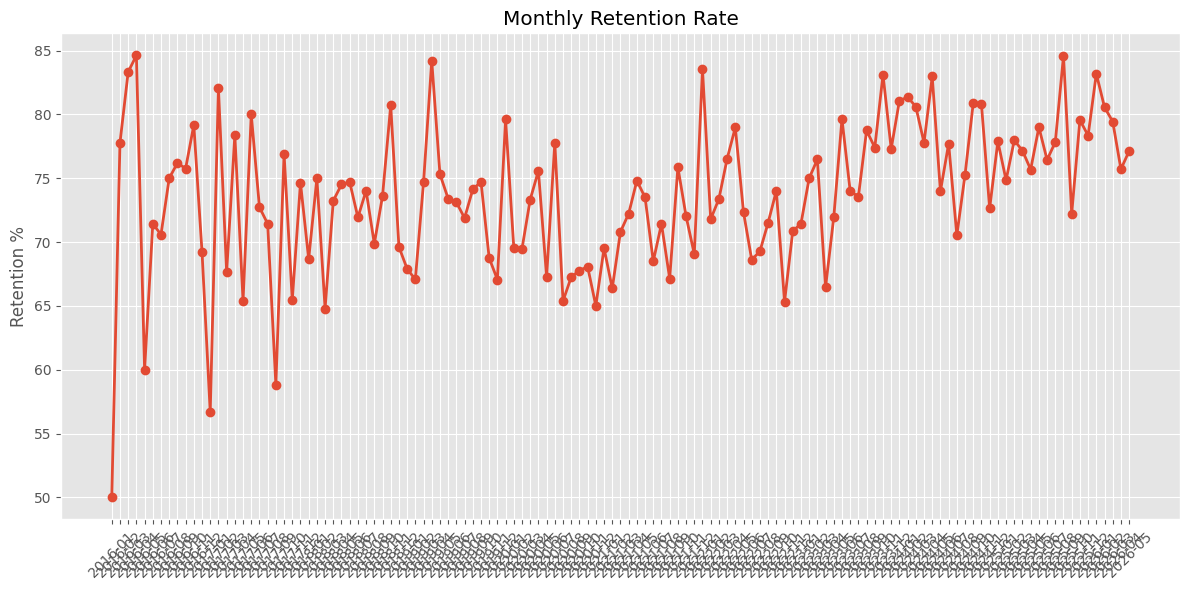

In [63]:
plt.figure(figsize=(12,6))

plt.plot(

    retention.index.astype(str),

    retention["Retention %"],

    marker="o",

    linewidth=2

)

plt.xticks(rotation=45)

plt.title("Monthly Retention Rate")

plt.ylabel("Retention %")

plt.grid(True)

plt.tight_layout()

plt.savefig(

    "charts/Retention_Rate.png",

    dpi=300

)

plt.show()

In [64]:
title_hours=(

    eda

    .groupby("title_name")

    ["Watch Hours"]

    .sum()

    .sort_values(

        ascending=False

    )

)

top10=max(

    int(len(title_hours)*0.10),

    1

)

top_hours=title_hours.head(top10).sum()

overall_hours=title_hours.sum()

hit_concentration=round(

    top_hours

    /

    overall_hours

    *100,

    2

)

logger.info(

    f"Hit Concentration : {hit_concentration}%"

)

kpi["Hit Concentration (%)"]=hit_concentration

2026-07-21 22:42:36,292 | INFO | Hit Concentration : 50.6%


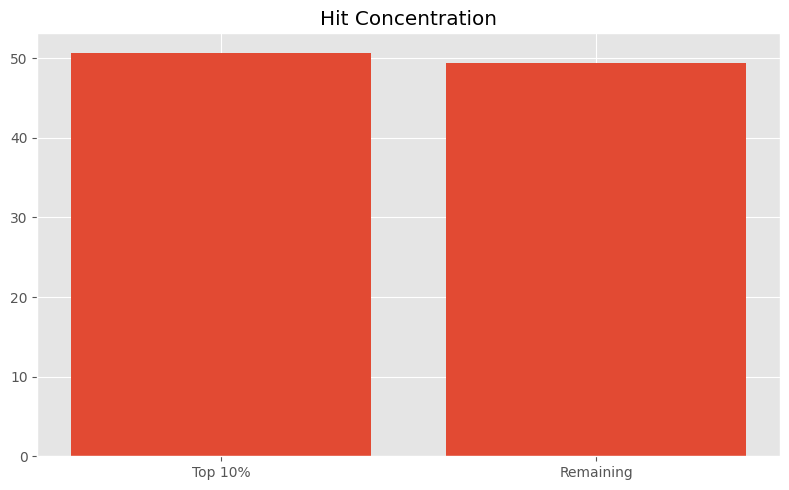

In [65]:
plt.figure(figsize=(8,5))

plt.bar(

    ["Top 10%","Remaining"],

    [

        hit_concentration,

        100-hit_concentration

    ]

)

plt.title("Hit Concentration")

plt.tight_layout()

plt.savefig(

    "charts/Hit_Concentration.png",

    dpi=300

)

plt.show()

In [66]:
original_titles=titles[

    titles["is_original"]==True

].shape[0]

licensed_titles=titles.shape[0]-original_titles

original_share=round(

    original_titles

    /

    titles.shape[0]

    *100,

    2

)

logger.info(

    f"Original Content Share : {original_share}%"

)

kpi["Original Content Share (%)"]=original_share

2026-07-21 22:42:39,256 | INFO | Original Content Share : 21.84%


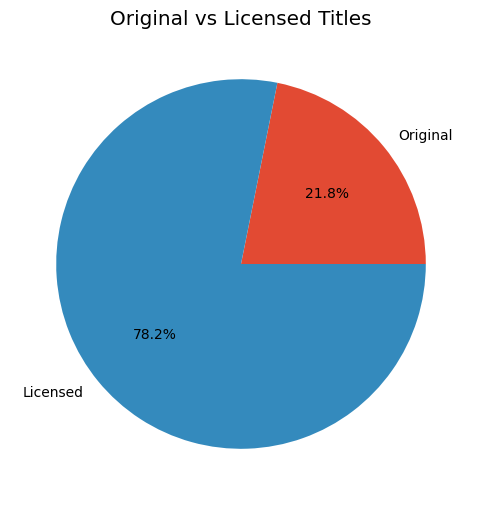

In [67]:
plt.figure(figsize=(6,6))

plt.pie(

    [original_titles,licensed_titles],

    labels=["Original","Licensed"],

    autopct="%1.1f%%"

)

plt.title("Original vs Licensed Titles")

plt.savefig(

    "charts/Original_vs_Licensed.png",

    dpi=300

)

plt.show()

In [68]:
scorecard=pd.DataFrame({

    "Metric":[

        "Subscribers",

        "MRR",

        "ARPU",

        "Retention",

        "Churn",

        "Watch Hours",

        "Completion",

        "Rating",

        "Hit Concentration",

        "Original Share"

    ],

    "Value":[

        total_subscribers,

        MRR,

        ARPU,

        retention["Retention %"].mean(),

        churn_rate,

        watch_hours,

        completion,

        rating,

        hit_concentration,

        original_share

    ]

})

scorecard

scorecard.to_csv(
    "reports/Executive_Scorecard.csv",
    index=False
)

logger.info("Executive Scorecard Exported")

2026-07-21 22:42:42,496 | INFO | Executive Scorecard Exported


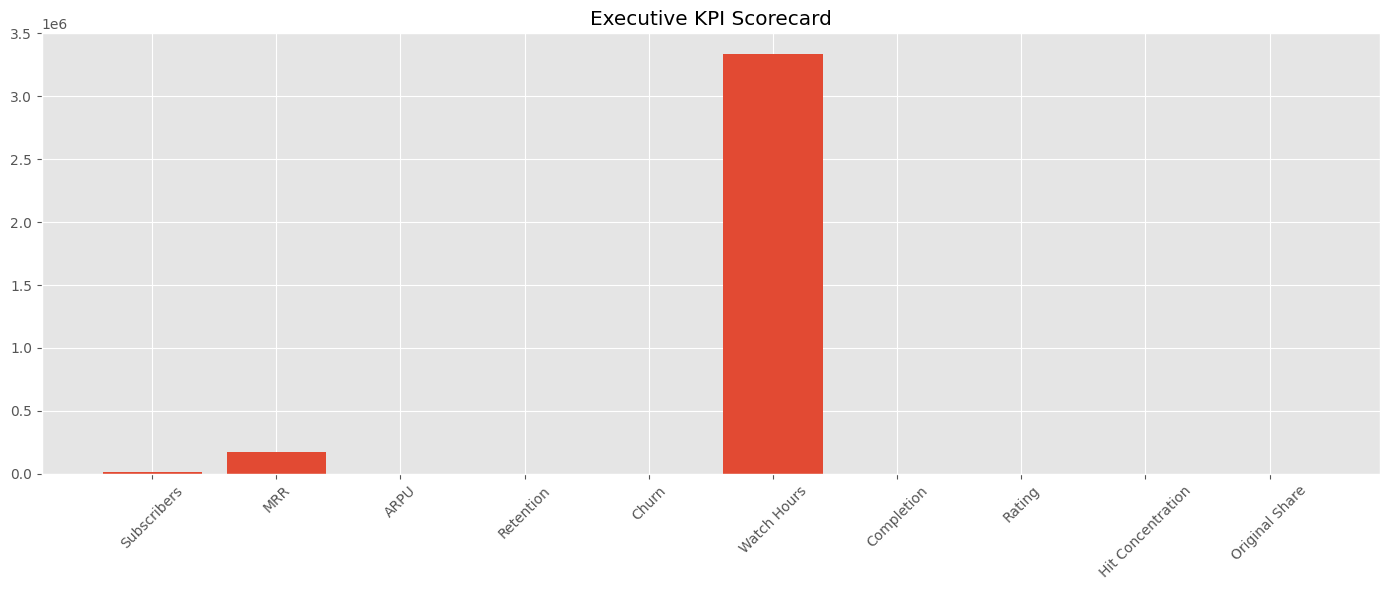

In [69]:
plt.figure(figsize=(14,6))

plt.bar(

    scorecard["Metric"],

    scorecard["Value"]

)

plt.xticks(rotation=45)

plt.title("Executive KPI Scorecard")

plt.tight_layout()

plt.savefig(

    "charts/Executive_Scorecard.png",

    dpi=300

)

plt.show()

In [70]:
kpi_df=pd.DataFrame(

    kpi.items(),

    columns=[

        "KPI",

        "Value"

    ]

)

kpi_df.to_csv(

    "reports/Final_KPI_Report.csv",

    index=False

)

In [71]:
summary=[]

summary.append(

    f"Total Subscribers : {total_subscribers}"

)

summary.append(

    f"Monthly Recurring Revenue : ${MRR}"

)

summary.append(

    f"Average Revenue Per User : ${ARPU}"

)

summary.append(

    f"Retention Rate : {round(retention['Retention %'].mean(),2)}%"

)

summary.append(

    f"Churn Rate : {churn_rate}%"

)

summary.append(

    f"Total Watch Hours : {watch_hours}"

)

summary.append(

    f"Average Completion : {completion}%"

)

summary.append(

    f"Average Rating : {rating}"

)

summary.append(

    f"Hit Concentration : {hit_concentration}%"

)

summary.append(

    f"Original Share : {original_share}%"

)

with open(

    "reports/Management_Summary.txt",

    "w",

    encoding="utf-8"

) as file:

    file.write(

        "STREAMFLIX MANAGEMENT REPORT\n\n"

    )

    for line in summary:

        file.write(line+"\n")

logger.info(

    "Management Summary Generated"

)

2026-07-21 22:42:47,111 | INFO | Management Summary Generated


In [72]:
logger.info("="*80)

logger.info("PHASE 3 COMPLETED SUCCESSFULLY")

logger.info("="*80)

print("="*80)

print("PHASE 3 COMPLETED SUCCESSFULLY")

print("="*80)

2026-07-21 22:42:48,780 | INFO | ================================================================================
2026-07-21 22:42:48,782 | INFO | PHASE 3 COMPLETED SUCCESSFULLY
2026-07-21 22:42:48,783 | INFO | ================================================================================


PHASE 3 COMPLETED SUCCESSFULLY
